In [1]:
#Librerias
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
from scipy.stats import probplot, f as fdist
from math import radians, sin, cos, sqrt, atan2

### **Propuesta de Reespecificación del Modelo**

Basado en los diagnósticos de la primera etapa (Test de Ramsey RESET y Breusch-Pagan), se busco obtener una nueva base de datos, con más variables para capturar la complejidad del mercado inmobiliario en Puebla, además se incluyeron variables dummy para no solo tomar en cuenta el zócalo de Puebla sino otras zona de plusvalia.

- **Dummies de zona** (categoría base = San Manuel, excluida):
  - `z_ang_i` = está en Angelópolis (1=sí, 0=no)
  - `z_chol_i` = está en Cholula (1=sí, 0=no)
  - `z_sda_i` = está en San Andrés (1=sí, 0=no)
  - `z_vw_i` = está en Lomas VW (1=sí, 0=no)
  - `z_paz_i` = está en La Paz (1=sí, 0=no)
  - `z_anim_i` = está en Las Ánimas (1=sí, 0=no)
  - *(San Manuel es la categoría omitida = línea base)*

 **Datos:** 180 propiedades de Inmuebles24 (corte transversal)

#### **1. Modelo Lineal Propuesto**


$$P_i = \beta_0 + \beta_1 m2_i + \beta_2 recamaras_i + \beta_3 banos_i + \beta_4 estac_i + \beta_5 antiguedad_i + \beta_6 roof_i + \beta_7 alb_i + \beta_8 casa_i + \beta_{9} dist\_zoc^2_i + \beta_{10} z\_ang_i + \beta_{11} z\_chol_i + \beta_{12} z\_sda_i + \beta_{13} z\_vw_i + \beta_{14} z\_paz_i + \beta_{15} z\_anim_i + \varepsilon_i$$

Donde:
* $Baños\_Tot_i = Baños\_Completos_i + 0.5(Medios\_Baños_i)$


De igual manera se probarán, varias interacciones entre variables como:

- **Interacciones** :
  - `ln(m2)·alb_i` = elasticidad de m² diferente si hay alberca
  - `ln(m2)·antig_i` = elasticidad de m² cambia con antigüedad
  - `roof_i·alb_i` = efecto adicional si tiene AMBAS amenidades


In [2]:
#Primero obtengamos los datos de la base de datos
df_datos = pd.read_csv('propiedades_puebla.csv')

print(f'Base cargada: {df_datos.shape[0]} obs x {df_datos.shape[1]} variables')
print(f'Tipos: {df_datos["tipo"].value_counts().to_dict()}')
print('\nVALORES FALTANTES:')
miss = df_datos.isnull().sum()
print(miss[miss > 0].to_string())
print()
df_datos.describe().round(2)

Base cargada: 180 obs x 15 variables
Tipos: {'departamentos': 90, 'casas': 90}

VALORES FALTANTES:
estacionamientos    11
antiguedad_anos     91



,precio_mxn,m2,recamaras,banos,medios_banos,estacionamientos,antiguedad_anos,pisos,latitud,longitud,roof_garden,alberca
count,180.00,180.00,180.00,180.00,180.00,169.00,89.00,180.0,180.00,180.00,180.00,180.00
mean,4955877.98,252.53,2.94,2.99,2.49,2.34,15.45,1.5,19.03,-98.23,0.26,0.08
std,6559728.99,701.82,0.42,1.84,1.65,1.75,12.73,0.5,0.04,0.03,0.44,0.28
min,780000.00,0.00,1.00,1.00,1.00,1.00,1.00,1.0,18.92,-98.30,0.00,0.00
25%,2100000.00,85.00,3.00,2.00,2.00,1.00,6.00,1.0,19.01,-98.25,0.00,0.00
50%,3000000.00,115.00,3.00,3.00,2.00,2.00,12.00,1.5,19.05,-98.24,0.00,0.00
75%,4500000.00,215.00,3.00,3.00,3.00,2.00,22.00,2.0,19.06,-98.21,1.00,0.00
max,55000000.00,9134.00,4.00,16.00,12.00,10.00,59.00,2.0,19.09,-98.13,1.00,1.00


Viendo el resumen nos llama la atención que en metros cuadrados haya un valor minimo de 0, además de un valor maximo de 9134 (no muy realista), esto tal vez se deba a la forma de obtener los datos que usamos. Pudo deberse a un error en la página o un error de captura del vendedor. por lo que aplicaremos un tratamiento para quitar estos datos erróneos.

In [3]:
#Eliminar errores graves en la captura de datos
df = df_datos.copy()

# Obs con m2=0
n0 = len(df)
df = df[df['m2'] > 0].copy()
print(f'Eliminadas por m2=0: {n0-len(df)} obs.')

# Departamento con m2=9134 (error de captura: terreno vs construccion)
n0 = len(df)
df = df[~((df['m2'] > 2000) & (df['tipo']=='departamentos'))].copy()
print(f'Eliminadas deptos con m2>2000: {n0-len(df)} obs.')
print(f'Base limpia: {len(df)} observaciones')

Eliminadas por m2=0: 1 obs.
Eliminadas deptos con m2>2000: 1 obs.
Base limpia: 178 observaciones


De igual manera, vemos que hay varias observaciones faltantes para algunas variables como: estacionamiento y antiguedad. Por la forma en que se obtuvo la base de datos, sabemos que si hay datos faltantes significa que no tiene esas amenidades, por lo que hay que rellenarlas con "0"

In [4]:
# Estacionamientos (11 nulos): fillna(0) segun la base de datos
df['estacionamientos'] = df['estacionamientos'].fillna(0)

# Antiguedad
df['antiguedad_anos'] = df['antiguedad_anos'].fillna(0)

print(f'Nulos restantes: {df.isnull().sum().sum()}')
print(f'Base final: {len(df)} observaciones')

Nulos restantes: 0
Base final: 178 observaciones


In [5]:
#Extraemos las variables
# Banos totales: bano completo=1, medio bano=0.5
df['banos_tot'] = df['banos'] + 0.5 * df['medios_banos']

#Dummy tipo propiedad
df['es_casa'] = (df['tipo']=='casas').astype(int)

#Transformaciones logaritmicas
df['ln_precio'] = np.log(df['precio_mxn'])
df['ln_m2']     = np.log(df['m2'])

#Coordenadas de zona de Plusvalia en Puebla y uso de Dummies
ZONAS = {
    'zocalo':       (19.0437, -98.1978),  # Centro Histórico
    'angelopolis':  (19.0397, -98.2342),  # Estrella de Puebla / centro comercial
    'cholula':      (19.0631, -98.3014),  # San Pedro Cholula centro
    'san_andres':   (19.0537, -98.2840),  # San Andrés Cholula centro
    'lomas_vw':     (19.1505, -98.2603),  # Lomas VW / San Lorenzo Almecatla
    'la_paz':       (19.0510, -98.2188),  # Colonia La Paz
    'las_animas':   (19.0327, -98.2150),  # Las Ánimas
    'san_manuel':   (19.0188, -98.2050),  # San Manuel (zona BUAP)
}

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2-lat1); dlon = radians(lon2-lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

#Calcular distancia a cada zona
for nombre, (lat, lon) in ZONAS.items():
    df[f'd_{nombre}_km'] = df.apply(
        lambda r: haversine(r['latitud'], r['longitud'], lat, lon), axis=1
    )

#Distancia continua al Zócalo (componente A de la estrategia híbrida)
df['dist_zocalo_km'] = df['d_zocalo_km']

#Distancia al Zócalo al cuadrado ya que los primeros km importan más
df['dist_zocalo_km2'] = df['dist_zocalo_km'] ** 2

#Asignar cada propiedad a la ZONA MÁS CERCANA (excepto Zócalo, que es continuo)
zona_dist_cols = [f'd_{z}_km' for z in ZONAS if z != 'zocalo']
df['zona'] = df[zona_dist_cols].idxmin(axis=1).str.replace('d_','').str.replace('_km','')

#Crear dummies de zona (componente B de la estrategia híbrida)
#Categoría base = 'san_manuel' (zona universitaria, residencial media)
# Drop any existing zona_ columns to ensure a clean slate if cell is rerun
current_zona_cols = [c for c in df.columns if c.startswith('zona_')]
if current_zona_cols:
    df = df.drop(columns=current_zona_cols, errors='ignore')

zona_dummies = pd.get_dummies(df['zona'], prefix='zona', drop_first=False).astype(int)
df = pd.concat([df, zona_dummies], axis=1)

#Dummy tipo propiedad
df['es_casa'] = (df['tipo']=='casas').astype(int)

#Transformaciones logarítmicas
df['ln_precio'] = np.log(df['precio_mxn'])
df['ln_m2']     = np.log(df['m2'])

#Interacciones propuestas
df['inter_m2_alberca']    = df['ln_m2'] * df['alberca']
df['inter_m2_antiguedad'] = df['ln_m2'] * df['antiguedad_anos']
df['inter_rg_alberca']    = df['roof_garden'] * df['alberca']

print('Variables construidas exitosamente.')
print()
print('DISTRIBUCIÓN DE PROPIEDADES POR ZONA (zona más cercana):')
print(df['zona'].value_counts().to_string())
print()

Variables construidas exitosamente.

DISTRIBUCIÓN DE PROPIEDADES POR ZONA (zona más cercana):
zona
angelopolis    53
san_manuel     52
la_paz         41
san_andres     20
las_animas     12



Vemos que no existen observaciones para las zonas de cholula y vw, por lo que se les excluir+a del listado de zonas de plus valia.

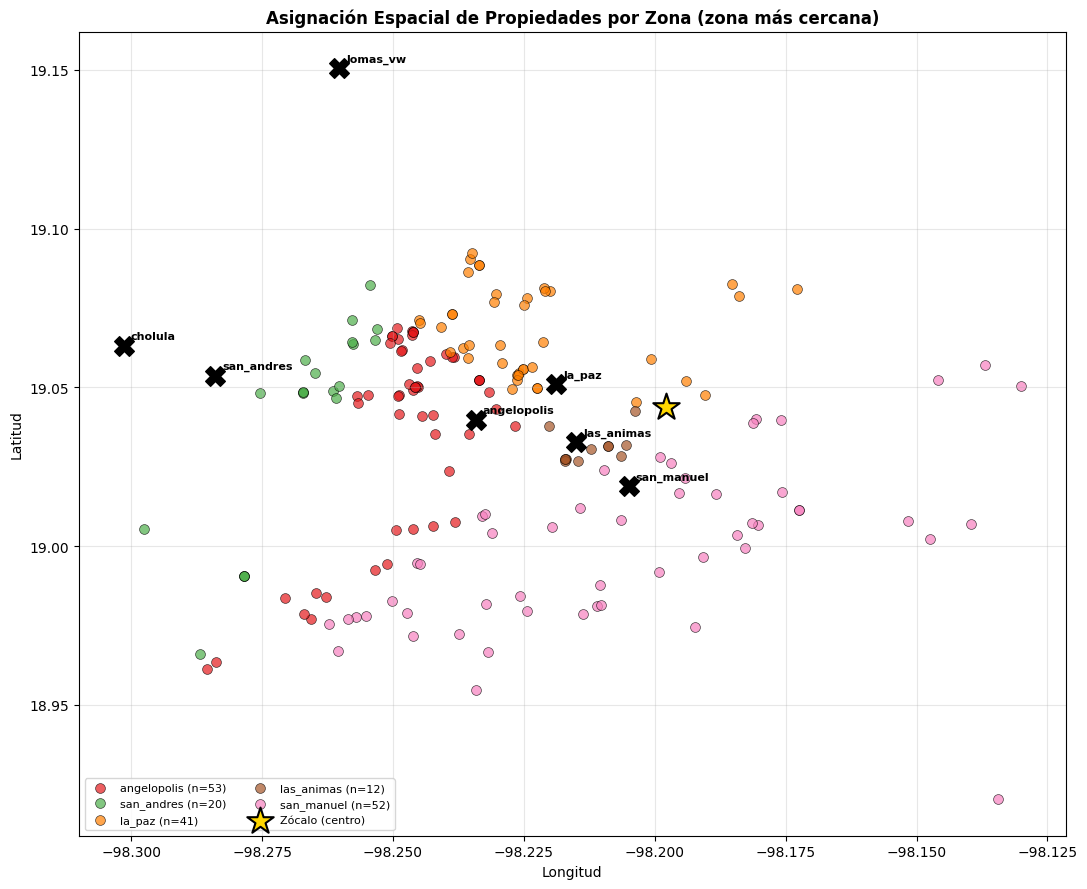

Mapa guardado en mapa_zonas.png


In [6]:
# Visualización de la asignación de zonas en mapa
fig, ax = plt.subplots(figsize=(11, 9))

colores_zona = {
    'angelopolis': '#e41a1c', 'cholula':    '#377eb8', 'san_andres': '#4daf4a',
    'lomas_vw':    '#984ea3', 'la_paz':     '#ff7f00', 'las_animas': '#a65628',
    'san_manuel':  '#f781bf'
}

for zona, color in colores_zona.items():
    sub = df[df['zona']==zona]
    if len(sub) > 0:
        ax.scatter(sub['longitud'], sub['latitud'], c=color, s=50, alpha=0.7,
                   edgecolor='black', linewidth=0.5,
                   label=f'{zona} (n={len(sub)})')

# Centroides de zonas como X grande
for zona, (lat, lon) in ZONAS.items():
    if zona == 'zocalo':
        ax.scatter(lon, lat, marker='*', s=400, c='gold', edgecolor='black',
                   linewidth=1.5, zorder=5, label='Zócalo (centro)')
    else:
        ax.scatter(lon, lat, marker='X', s=200, c='black', zorder=4)
        ax.annotate(zona, (lon, lat), fontsize=8, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.set_title('Asignación Espacial de Propiedades por Zona (zona más cercana)',
             fontsize=12, fontweight='bold')
ax.legend(loc='lower left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mapa_zonas.png', dpi=150, bbox_inches='tight')
plt.show()


print('Mapa guardado en mapa_zonas.png')

## 3. Analisis Exploratorio (EDA)

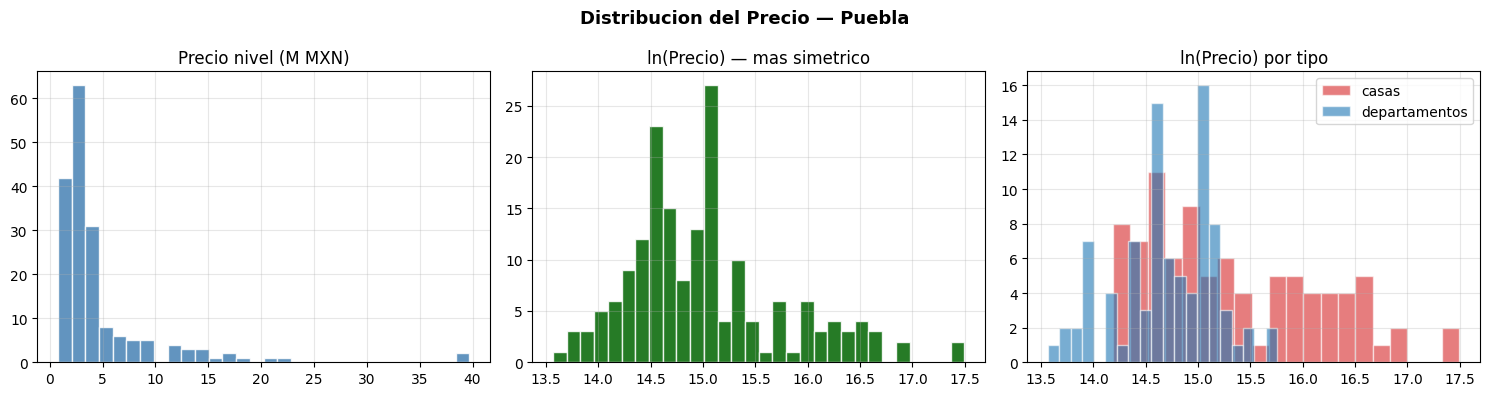

Precio mediano — Casas: $3.50M | Deptos: $2.45M


In [7]:
# Distribucion del precio
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribucion del Precio — Puebla', fontsize=13, fontweight='bold')

axes[0].hist(df['precio_mxn']/1e6, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Precio nivel (M MXN)'); axes[0].grid(True, alpha=0.3)

axes[1].hist(df['ln_precio'], bins=30, color='darkgreen', edgecolor='white', alpha=0.85)
axes[1].set_title('ln(Precio) — mas simetrico'); axes[1].grid(True, alpha=0.3)

for tipo, color in [('casas','#d62728'),('departamentos','#1f77b4')]:
    axes[2].hist(df[df['tipo']==tipo]['ln_precio'],
                bins=20, alpha=0.6, color=color, label=tipo, edgecolor='white')
axes[2].set_title('ln(Precio) por tipo'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_precio.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Precio mediano — Casas: ${df[df["tipo"]=="casas"]["precio_mxn"].median()/1e6:.2f}M'
      f' | Deptos: ${df[df["tipo"]=="departamentos"]["precio_mxn"].median()/1e6:.2f}M')

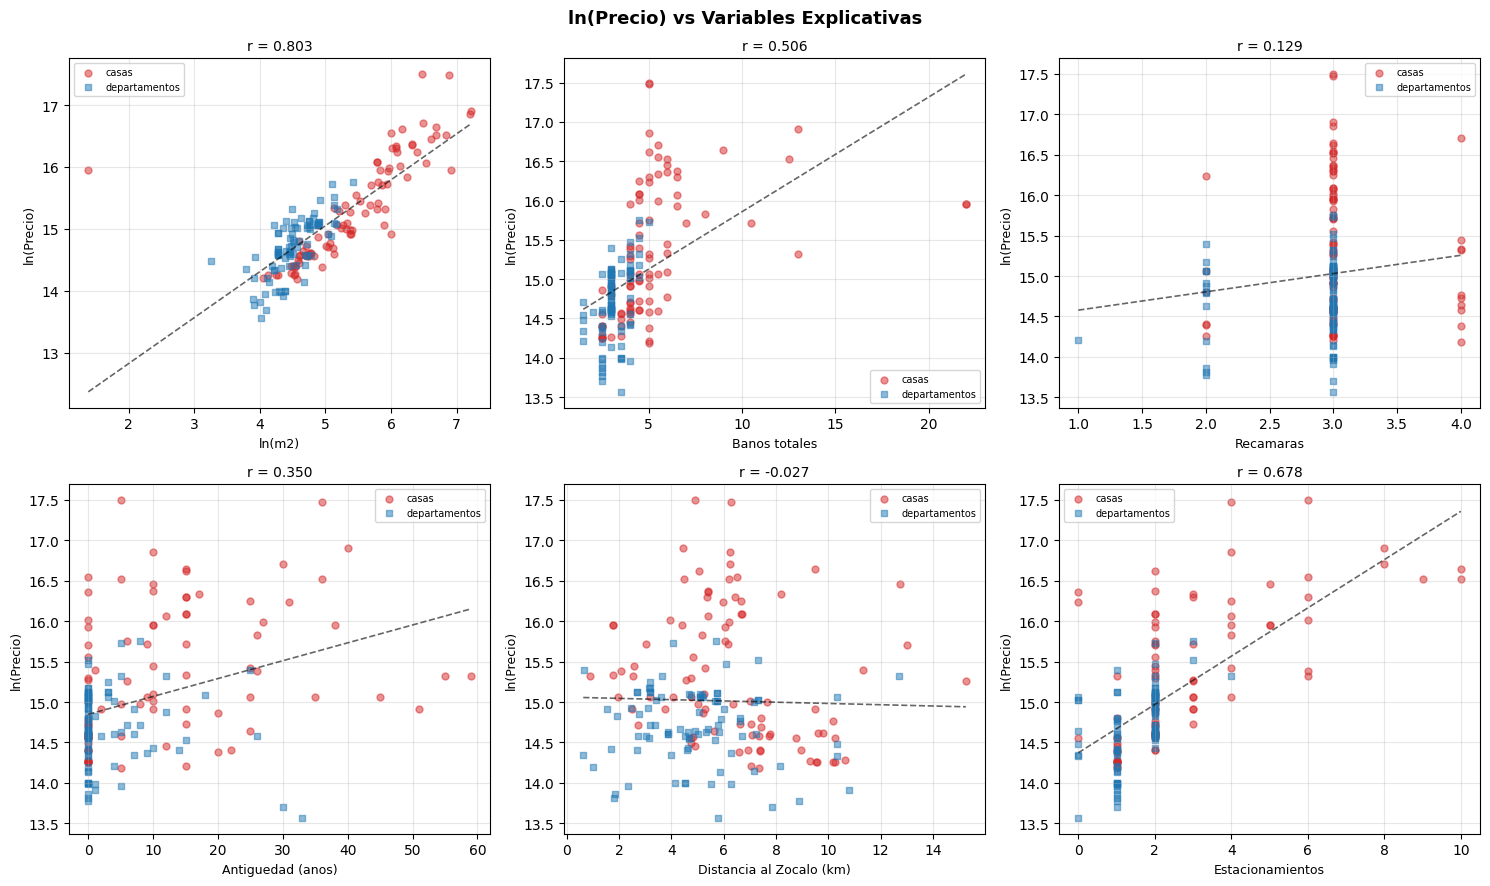

In [8]:
# Grafico ln(precio) vs predictores
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('ln(Precio) vs Variables Explicativas', fontsize=13, fontweight='bold')

vars_sc = [('ln_m2','ln(m2)','steelblue'),('banos_tot','Banos totales','darkgreen'),
           ('recamaras','Recamaras','darkorange'),('antiguedad_anos','Antiguedad (anos)','purple'),
           ('dist_zocalo_km','Distancia al Zocalo (km)','crimson'),
           ('estacionamientos','Estacionamientos','teal')]

for ax, (var, label, color) in zip(axes.flatten(), vars_sc):

    plot_df = df[[var, 'ln_precio', 'tipo']].dropna(subset=[var, 'ln_precio'])

    for tipo, mc_, col in [('casas','o','#d62728'),('departamentos','s','#1f77b4')]:
        sub = plot_df[plot_df['tipo']==tipo]
        ax.scatter(sub[var], sub['ln_precio'], alpha=0.5, color=col, s=25, marker=mc_, label=tipo)

    if len(plot_df) > 1: # Al menos necesitamos 2 puntos para la regresión
        z = np.polyfit(plot_df[var], plot_df['ln_precio'], 1)
        xr = np.linspace(plot_df[var].min(), plot_df[var].max(), 100)
        ax.plot(xr, np.poly1d(z)(xr), 'k--', lw=1.2, alpha=0.6)
    else:
        pass

    ax.set_xlabel(label, fontsize=9); ax.set_ylabel('ln(Precio)', fontsize=9)
    if len(plot_df) > 1:
        ax.set_title(f'r = {plot_df["ln_precio"].corr(plot_df[var]):.3f}', fontsize=10)
    else:
        ax.set_title(f'r = N/A', fontsize=10)

    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('scatter_predictores.png', dpi=150, bbox_inches='tight')
plt.show()

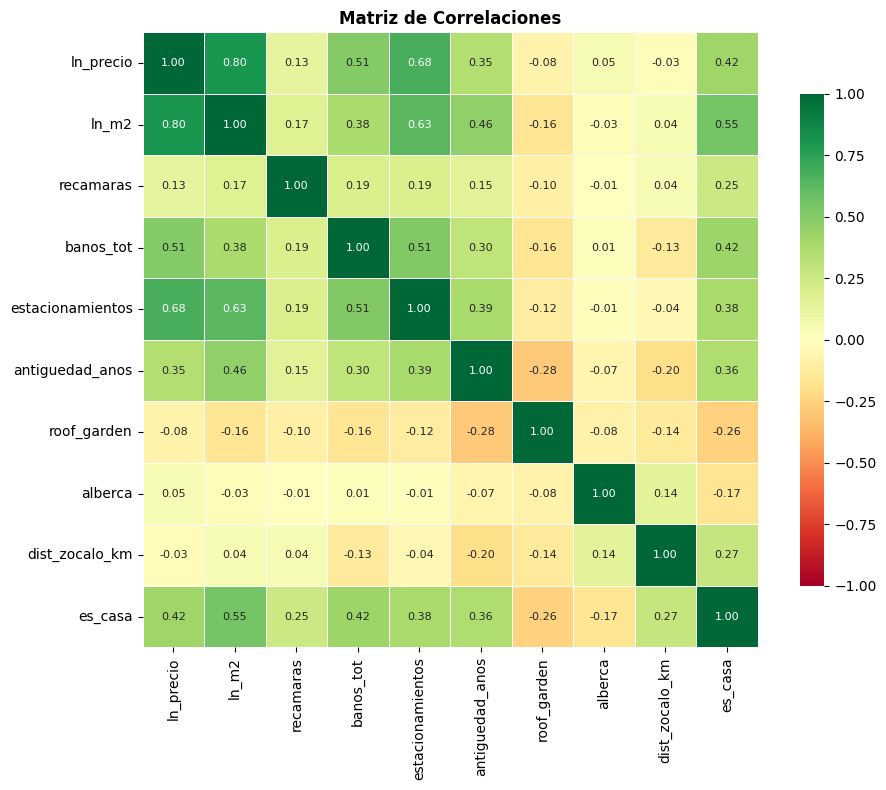

Correlaciones con ln(precio):
ln_m2               0.803
estacionamientos    0.678
banos_tot           0.506
es_casa             0.421
antiguedad_anos     0.350
recamaras           0.129
alberca             0.055
dist_zocalo_km     -0.027
roof_garden        -0.081


In [9]:
# Mapa de correlaciones
vars_corr = ['ln_precio','ln_m2','recamaras','banos_tot','estacionamientos',
             'antiguedad_anos','roof_garden','alberca','dist_zocalo_km','es_casa']
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[vars_corr].corr()
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True, annot_kws={'size':8},
            linewidths=0.5, cbar_kws={'shrink':0.8})
ax.set_title('Matriz de Correlaciones', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Correlaciones con ln(precio):')
print(corr['ln_precio'].drop('ln_precio').sort_values(ascending=False).round(3).to_string())

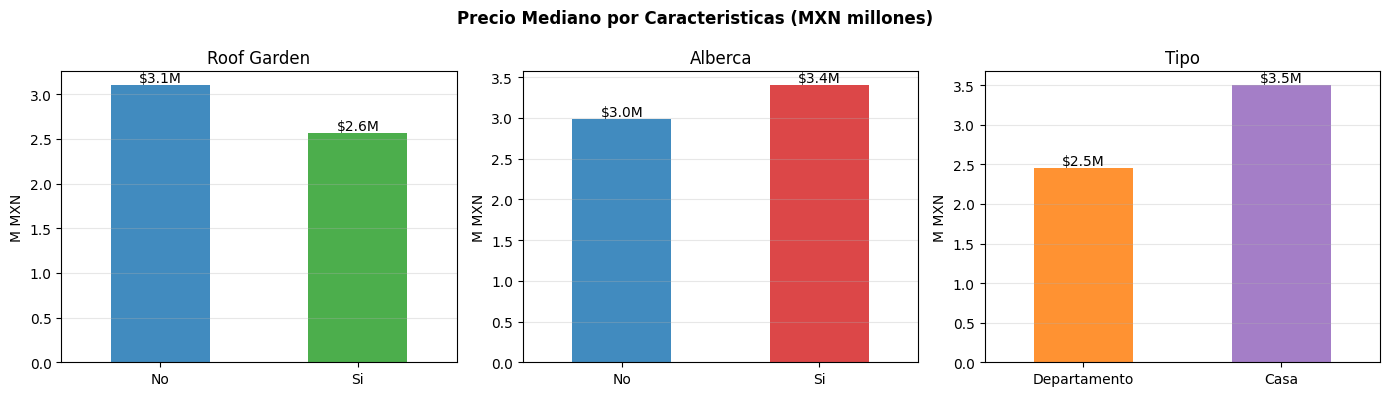

In [10]:
# Precio mediano por amenidades
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Precio Mediano por Caracteristicas (MXN millones)', fontsize=12, fontweight='bold')

for ax, (var, lab, etiquetas, cols) in zip(axes, [
    ('roof_garden','Roof Garden',['No','Si'],['#1f77b4','#2ca02c']),
    ('alberca','Alberca',['No','Si'],['#1f77b4','#d62728']),
    ('es_casa','Tipo',['Departamento','Casa'],['#ff7f0e','#9467bd'])
]):
    grupos = df.groupby(var)['precio_mxn'].median() / 1e6
    grupos.index = etiquetas
    grupos.plot(kind='bar', ax=ax, color=cols, alpha=0.85, width=0.5)
    ax.set_title(lab); ax.set_ylabel('M MXN'); ax.tick_params(axis='x', rotation=0)
    ax.grid(True, alpha=0.3, axis='y')
    for p in ax.patches:
        ax.annotate(f'${p.get_height():.1f}M', (p.get_x()+p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('precio_amenidades.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Estimacion de Modelos

## Notación
**Variables dependientes:**
  - M1: `P_i` = precio en MXN (nivel)
  - M2, M3, M4, M5: `ln(P_i)` = logaritmo natural del precio

- **Variables continuas:**
  - `m2_i` = metros cuadrados
  - `ln(m2_i)` = logaritmo natural de metros cuadrados
  - `rec_i` = número de recámaras
  - `ban_i` = baños totales (baño completo = 1, medio baño = 0.5)
  - `est_i` = número de estacionamientos
  - `antig_i` = antigüedad en años
  - `dist_zoc_i` = distancia al Zócalo en km

- **Variables dummy:**
  - `roof_i` = tiene roof garden (1=sí, 0=no)
  - `alb_i` = tiene alberca (1=sí, 0=no)
  - `casa_i` = es casa (1=casa, 0=departamento)
  - `imputa_i` = antigüedad fue imputada (1=sí, 0=no)


## MODELO 1 — Lineal-Lineal

**Ecuación estructural:**

$$P_i = \beta_0 + \beta_1 m2_i + \beta_2 recamaras_i + \beta_3 banos_i + \beta_4 estac_i + \beta_5 antiguedad_i + \beta_6 roof_i + \beta_7 alb_i + \beta_8 casa_i + \beta_{9} dist\_zoc^2_i + \beta_{10} z\_ang_i + \beta_{11} z\_chol_i + \beta_{12} z\_sda_i + \beta_{13} z\_vw_i + \beta_{14} z\_paz_i + \beta_{15} z\_anim_i + \varepsilon_i$$

In [11]:
y = df['precio_mxn']

# Variables base (sin zonas)
VARS_BASE = ['recamaras','banos_tot','estacionamientos','antiguedad_anos',
             'roof_garden','alberca','es_casa']

# Dummies de zona (categoría base = san_manuel, la más numerosa después de angelópolis)
# Excluimos zona_san_manuel para evitar la trampa de las variables dummy
# Explicitly define the dummy variables to avoid accidental extra columns
ZONAS_DUMMIES = ['zona_angelopolis', 'zona_la_paz', 'zona_las_animas', 'zona_san_andres']

print(f'Dummies de zona incluidas: {ZONAS_DUMMIES}')
print(f'Categoría base: zona_san_manuel')
print()

# Modelo 1: Lineal-lineal
# Explicitly construct the list of exogenous variables
m1_exog_vars = ['m2'] + VARS_BASE + ['dist_zocalo_km2'] + ZONAS_DUMMIES

# Create a clean DataFrame for X_m1 to avoid issues with extraneous columns in df
df_for_m1 = df[m1_exog_vars].copy()

X_m1 = sm.add_constant(df_for_m1)
m1 = sm.OLS(df['precio_mxn'], X_m1).fit(cov_type='HC3')

print(m1.summary())

Dummies de zona incluidas: ['zona_angelopolis', 'zona_la_paz', 'zona_las_animas', 'zona_san_andres']
Categoría base: zona_san_manuel

                            OLS Regression Results                            
Dep. Variable:             precio_mxn   R-squared:                       0.716
Model:                            OLS   Adj. R-squared:                  0.694
Method:                 Least Squares   F-statistic:                     10.72
Date:                Wed, 20 May 2026   Prob (F-statistic):           2.71e-16
Time:                        22:16:42   Log-Likelihood:                -2899.7
No. Observations:                 178   AIC:                             5827.
Df Residuals:                     164   BIC:                             5872.
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025    

- Fácil interpretación en pesos
- Supone relación lineal rígida; no captura que el efecto de m² es mayor en casas caras que en deptos baratos


## MODELO 2 — Log-Log
Ahora intentaremos un modelo log-log, ya que como sabemos por la teoria inmobilaria el precio y los metros cuadrados, no tienen una relación lineal.


**Ecuación estructural:**

$$\ln(P_i) = \beta_0 + \beta_1 \ln(m2_i) + \beta_2 recamaras_i + \beta_3 banos_i + \beta_4 estac_i + \beta_5 antiguedad_i + \beta_6 roof_i + \beta_7 alb_i + \beta_8 casa_i + \beta_{9} dist\_zoc^2_i + \beta_{10} z\_ang_i + \beta_{11} z\_chol_i + \beta_{12} z\_sda_i + \beta_{13} z\_vw_i + \beta_{14} z\_paz_i + \beta_{15} z\_anim_i + \varepsilon_i$$


In [12]:
# Modelo 2: Log-log
y = df['ln_precio']
VARS_BASE = ['recamaras','banos_tot','estacionamientos','antiguedad_anos',
             'roof_garden','alberca','es_casa']

X_m2 = sm.add_constant(df[['ln_m2'] + VARS_BASE + ['dist_zocalo_km2'] + ZONAS_DUMMIES])
m2 = sm.OLS(y, X_m2).fit(cov_type='HC3')


print(m2.summary())


                            OLS Regression Results                            
Dep. Variable:              ln_precio   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     32.14
Date:                Wed, 20 May 2026   Prob (F-statistic):           1.93e-38
Time:                        22:16:42   Log-Likelihood:                -53.852
No. Observations:                 178   AIC:                             135.7
Df Residuals:                     164   BIC:                             180.2
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               11.8263      1.560  

- No asume relación lineal rígida m² ↔ precio
- Permite que el valor del m² varíe según contexto
- Más flexible que M1 para datos de precios (que tienden a distribuirse lognormal)

## MODELO 3 — Log-Log + Algunas Interacciones

**Ecuación estructural:**


$$\ln(P_i) = \beta_0 + \beta_1 \ln(m2_i) +  \beta_2 banos_i + \beta_3 estacionamiento_i + \beta_4 roof_i + \beta_5 alberca_i + \beta_6 casa_i + \beta_7 [m2 \times casa_i] + \beta_8 [m2 \times antiguedad_i] + \beta_9 [m2 \times banos_i] + \beta_{10} ln(dist\_zoc_i) + \beta_{11} z\_ang_i + \beta_{12} z\_cholula_i + \beta_{13} z\_sda_i + \beta_{14} z\_vw_i + \beta_{15} z\_paz_i + \beta_{16} z\_animas_i + \varepsilon_i$$

In [13]:
# Modelo 3: Log-log + algunas interacciones
y = df['ln_precio']

VARS_BASE = ['banos_tot','estacionamientos',
             'roof_garden','alberca','es_casa']

# Interacciones alternativas
df['inter_m2_casa']      = df['m2'] * df['es_casa']
df['inter_banos_m2']     = df['banos_tot'] * df['ln_m2']
df['ln_dist_zocalo'] = np.log(df['dist_zocalo_km'] + 0.1) #para evitar log (0)

VARS_I = VARS_BASE + ['inter_m2_casa','inter_m2_antiguedad',
                      'inter_banos_m2',
                      'ln_dist_zocalo']
X_m3 = sm.add_constant(df[['ln_m2'] + VARS_I + ['dist_zocalo_km2']+  ZONAS_DUMMIES])
m3 =  sm.OLS(y, X_m3).fit(cov_type='HC3')
print(m3.summary())


                            OLS Regression Results                            
Dep. Variable:              ln_precio   R-squared:                       0.882
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     60.22
Date:                Wed, 20 May 2026   Prob (F-statistic):           3.50e-58
Time:                        22:16:42   Log-Likelihood:                -9.8432
No. Observations:                 178   AIC:                             51.69
Df Residuals:                     162   BIC:                             102.6
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  10.3237    

- M2: asume que cada variable tiene efecto independiente
- M3: permite que el m² tenga "precio sombra" diferente según amenidades

## MODELO 4 — Log-Log con todas las interacciones


**Ecuación estructural:**

$$\ln(P_i) = \beta_0 + \beta_1 \ln(m2_i) + \beta_2 recamaras_i + \beta_3 banos_i + \beta_4 estacionamiento_i + \beta_5 antig_i + \beta_6 roof_i + \beta_7 alberca_i + \beta_8 casa_i +
 \beta_9 [m2 \times alberca_i] + \beta_{10} [m2 \times antiguedad_i] + \beta_{11} [roof \times alberca_i] + \beta_{12} [m2 \times casa_i] + \beta_{13} [m2 \times banos_i] + \beta_{14} ln(dist\_zoc_i) +
  \beta_{15} dist\_zoc_i + \beta_{16} z\_ang_i + \beta_{17} z\_cholula_i + \beta_{18} z\_sda_i + \beta_{19} z\_vw_i + \beta_{20} z\_paz_i + \beta_{21} z\_animas_i + \varepsilon_i$$

In [14]:
# Modelo 4: Log-log + TODAS las interacciones
y = df['ln_precio']

VARS_BASE = ['recamaras','banos_tot','estacionamientos','antiguedad_anos',
             'roof_garden','alberca','es_casa']
# Interacciones alternativas
df['inter_m2_casa']      = df['m2'] * df['es_casa']
df['inter_banos_m2']     = df['banos_tot'] * df['ln_m2']
df['ln_dist_zocalo'] = np.log(df['dist_zocalo_km'] + 0.1) #para evitar log (0)

VARS_I = VARS_BASE + ['inter_m2_alberca','inter_m2_antiguedad','inter_rg_alberca',
                      'inter_m2_casa','inter_banos_m2','ln_dist_zocalo' ]


X_m4 = sm.add_constant(df[['ln_m2'] + VARS_I + ['dist_zocalo_km2'] + ZONAS_DUMMIES])
m4 = sm.OLS(y, X_m4).fit(cov_type='HC3')
print(m4.summary())


                            OLS Regression Results                            
Dep. Variable:              ln_precio   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                     52.13
Date:                Wed, 20 May 2026   Prob (F-statistic):           4.70e-58
Time:                        22:16:42   Log-Likelihood:                -7.1003
No. Observations:                 178   AIC:                             54.20
Df Residuals:                     158   BIC:                             117.8
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  10.3221    

## MODELO 5 — Log-Log Simplificado (con estacionamientos)

**Ecuación estructural:**

$$\ln(P_i) = \beta_0 + \beta_1 \ln(m2_i) + \beta_2 estac_i + \beta_3 z\_ang_i + \beta_4 z\_la\_paz_i + \beta_5 z\_las\_animas_i + \beta_6 z\_san\_andres_i + \varepsilon_i$$

In [15]:
# Modelo 5: Log-log Simplificado (con estacionamientos y sin dist. al centro)
y = df['ln_precio']
VARS_M5 = ['estacionamientos']
X_m5 = sm.add_constant(df[['ln_m2'] + VARS_M5  + ZONAS_DUMMIES])
m5 = sm.OLS(y, X_m5).fit(cov_type='HC3')
print(m5.summary())

                            OLS Regression Results                            
Dep. Variable:              ln_precio   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.773
Method:                 Least Squares   F-statistic:                     74.93
Date:                Wed, 20 May 2026   Prob (F-statistic):           2.75e-45
Time:                        22:16:42   Log-Likelihood:                -64.999
No. Observations:                 178   AIC:                             144.0
Df Residuals:                     171   BIC:                             166.3
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               11.6404      0.882  

## MODELO 6 — Log-Log Solo distancia

**Ecuación estructural:**

$$\ln(P_i) = \beta_0 + \beta_1 \ln(m2_i) + \beta_2 dist\_zoc^2_i + \beta_3 z\_ang_i + \beta_4 z\_la\_paz_i + \beta_5 z\_las\_animas_i + \beta_6 z\_san\_andres_i + \varepsilon_i$$

In [16]:
# Modelo 6: Log-log Solo Distancia
y = df['ln_precio']
VARS_M6 = [] # Sin otras variables base
X_m6 = sm.add_constant(df[['ln_m2'] +['dist_zocalo_km2'] + VARS_M6 +  ZONAS_DUMMIES])
m6 = sm.OLS(y, X_m6).fit(cov_type='HC3')
print(m6.summary())

                            OLS Regression Results                            
Dep. Variable:              ln_precio   R-squared:                       0.719
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     39.49
Date:                Wed, 20 May 2026   Prob (F-statistic):           6.70e-30
Time:                        22:16:42   Log-Likelihood:                -87.113
No. Observations:                 178   AIC:                             188.2
Df Residuals:                     171   BIC:                             210.5
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               11.0430      0.612  

### Comparación de Modelos

In [17]:
print(f'  {"Modelo":<35} {"R2":>8} {"R2-adj":>8} {"AIC":>12} {"BIC":>12} {"n":>6}')
print(f'  {"-"*82}')
for nombre, mod, n in [
    ('M1 Lineal-lineal', m1, len(df)),
    ('M2 Log-log ', m2, len(df)),
    ('M3 Log-log + algunas interacciones', m3, len(df)),
    ('M4 Log-log + todas interacciones', m4, len(df)),
    ('M5 Log-log Simple con estac.', m5, len(df)),
    ('M6 Log-log solo distancia', m6, len(df)),
]:
    print(f'  {nombre:<35} {mod.rsquared:>8.4f} {mod.rsquared_adj:>8.4f} '
          f'{mod.aic:>12.2f} {mod.bic:>12.2f} {n:>6}')

print()

  Modelo                                    R2   R2-adj          AIC          BIC      n
  ----------------------------------------------------------------------------------
  M1 Lineal-lineal                      0.7161   0.6936      5827.43      5871.98    178
  M2 Log-log                            0.8066   0.7913       135.70       180.25    178
  M3 Log-log + algunas interacciones    0.8820   0.8711        51.69       102.59    178
  M4 Log-log + todas interacciones      0.8856   0.8719        54.20       117.84    178
  M5 Log-log Simple con estac.          0.7808   0.7731       144.00       166.27    178
  M6 Log-log solo distancia             0.7190   0.7091       188.23       210.50    178



In [18]:
bp_results = []

models = {
    'M1 Lineal-lineal': m1,
    'M2 Log-log': m2,
    'M3 Log-log + algunas interacciones': m3,
    'M4 Log-log + todas interacciones': m4,
    'M5 Log-log Simple con estac.': m5,
    'M6 Log-log solo distancia': m6,
}

for name, model in models.items():
    try:
        bp_test = sms.het_breuschpagan(model.resid, model.model.exog[:len(model.resid)])
        lm_stat = bp_test[0]
        p_value = bp_test[1]
        bp_results.append({'Modelo': name, 'LM Statistic': lm_stat, 'p-value': p_value})
    except Exception as e:
        print(f"Error calculating Breusch-Pagan for {name}: {e}")
        bp_results.append({'Modelo': name, 'LM Statistic': 'N/A', 'p-value': 'N/A'})

bp_df = pd.DataFrame(bp_results)

def interpret_p_value(p):
    if isinstance(p, (float, np.float64)):
        if p < 0.01: return 'Heteroscedasticidad (p < 0.01)'
        elif p < 0.05: return 'Heteroscedasticidad (p < 0.05)'
        elif p < 0.10: return 'Heteroscedasticidad (p < 0.10)'
        else: return 'No hay Heteroscedasticidad'
    return 'N/A'

bp_df['Conclusión'] = bp_df['p-value'].apply(interpret_p_value)

print("\n--- Resumen de Pruebas de Breusch-Pagan (Heteroscedasticidad) ---")
display(bp_df.round(4))



--- Resumen de Pruebas de Breusch-Pagan (Heteroscedasticidad) ---


,Modelo,LM Statistic,p-value,Conclusión
0,M1 Lineal-lineal,25.7700,0.0183,Heteroscedasticidad (p < 0.05)
1,M2 Log-log,98.7671,0.0000,Heteroscedasticidad (p < 0.01)
2,M3 Log-log + algunas interacciones,36.5703,0.0015,Heteroscedasticidad (p < 0.01)
3,M4 Log-log + todas interacciones,38.7691,0.0047,Heteroscedasticidad (p < 0.01)
4,M5 Log-log Simple con estac.,43.9309,0.0000,Heteroscedasticidad (p < 0.01)
5,M6 Log-log solo distancia,26.7396,0.0002,Heteroscedasticidad (p < 0.01)


Aunque en todos los modelos hay evidencia de heteroscedasticidad, nuestras conclusones siguen siendo validas pues se usó HC3 (errores robustos) para todos los modelos.

Por los resultados obtenidos, el mejor modelo parecer ser Modelo 3, aunque el modelo 2, ser bueno también. Hagamos algunas pruebas.

In [19]:

# Test F conjunto: las 3 interacciones mejoran significativamente?
f_inter = ((m2.ssr - m3.ssr)/3) / (m3.ssr/(len(df)-m3.df_model-1))
p_inter = 1 - fdist.cdf(f_inter, 3, len(df)-m3.df_model-1)
print(f'\n1.Test F conjunto de interacciones (M2 vs M3):')
print(f'  F(3, {len(df)-m3.df_model-1:.0f}) = {f_inter:.4f}  p-valor = {p_inter:.4f}')
print(f'  -> {"Interacciones MEJORAN significativamente el modelo" if p_inter<0.05 else "Interacciones NO mejoran (preferir M2 por parsimonia)"}')


1.Test F conjunto de interacciones (M2 vs M3):
  F(3, 162) = 34.5411  p-valor = 0.0000
  -> Interacciones MEJORAN significativamente el modelo


In [20]:

# Test F conjunto: las 3 interacciones mejoran significativamente?
f_inter = ((m3.ssr - m4.ssr)/3) / (m4.ssr/(len(df)-m4.df_model-1))
p_inter = 1 - fdist.cdf(f_inter, 3, len(df)-m4.df_model-1)
print(f'\n1.Test F conjunto de interacciones (M3 vs M4):')
print(f'  F(3, {len(df)-m4.df_model-1:.0f}) = {f_inter:.4f}  p-valor = {p_inter:.4f}')
print(f'  -> {"Interacciones MEJORAN significativamente el modelo" if p_inter<0.05 else "Interacciones NO mejoran (preferir M3 por parsimonia)"}')


1.Test F conjunto de interacciones (M3 vs M4):
  F(3, 158) = 1.6484  p-valor = 0.1804
  -> Interacciones NO mejoran (preferir M3 por parsimonia)


Elegiremos M3, para seguir haciendo mas pruebas.

In [21]:
# 3. Multicolinealidad (VIF)-M3
print('MULTICOLINEALIDAD (VIF) — Modelo 3')

X_vals = X_m3.values
vif_df = pd.DataFrame({
    'Variable': X_m3.columns,
    'VIF': [variance_inflation_factor(X_vals, i) for i in range(X_vals.shape[1])]
})
vif_df['Diagnostico'] = vif_df['VIF'].apply(
    lambda v: 'OK (<5)' if v<5 else ('Moderado (5-10)' if v<10 else 'ALTO (>10)')
)
print(vif_df.to_string(index=False))
print('\nUmbral: <5 OK | 5-10 monitorear | >10 problema')

MULTICOLINEALIDAD (VIF) — Modelo 3
           Variable        VIF     Diagnostico
              const 266.369629      ALTO (>10)
              ln_m2   7.996715 Moderado (5-10)
          banos_tot   9.380876 Moderado (5-10)
   estacionamientos   2.411753         OK (<5)
        roof_garden   1.197611         OK (<5)
            alberca   1.136408         OK (<5)
            es_casa   2.793053         OK (<5)
      inter_m2_casa   6.469309 Moderado (5-10)
inter_m2_antiguedad   1.942113         OK (<5)
     inter_banos_m2  13.121951      ALTO (>10)
     ln_dist_zocalo   4.364704         OK (<5)
    dist_zocalo_km2   3.120668         OK (<5)
   zona_angelopolis   1.843953         OK (<5)
        zona_la_paz   1.801581         OK (<5)
    zona_las_animas   1.702773         OK (<5)
    zona_san_andres   1.494129         OK (<5)

Umbral: <5 OK | 5-10 monitorear | >10 problema


In [22]:
print('='*55)
print('HETEROSCEDASTICIDAD — Modelo 3')
print('='*55)

bp = het_breuschpagan(m3.resid, m3.model.exog)
print(f'\nBreusch-Pagan: LM={bp[0]:.4f}  p={bp[1]:.4f}')
print(f'  -> {"Heteroscedasticidad detectada" if bp[1]<0.05 else "No se rechaza homoscedasticidad"}')

wh = het_white(m3.resid, m3.model.exog)
print(f'\nWhite:         LM={wh[0]:.4f}  p={wh[1]:.4f}')
print(f'  -> {"Heteroscedasticidad detectada" if wh[1]<0.05 else "No se rechaza homoscedasticidad"}')

print('\nCORRECCION: errores HC3 aplicados en todos los modelos.')

HETEROSCEDASTICIDAD — Modelo 3

Breusch-Pagan: LM=36.5703  p=0.0015
  -> Heteroscedasticidad detectada

White:         LM=136.0225  p=0.1228
  -> No se rechaza homoscedasticidad

CORRECCION: errores HC3 aplicados en todos los modelos.


In [23]:
# Test RESET (especificacion)
print('='*55)
print('TEST RESET — Especificacion funcional')
print('H0: modelo correctamente especificado')
print('='*55)

for nombre, mod in [('M3 Log-log + algunas interacciones', m3), ('M4 Log-log + todas interacciones', m4)]:
    r = linear_reset(mod, power=3, use_f=True)
    est = 'Posible mala especificacion' if r.pvalue<0.01 else 'Especificacion correcta'
    print(f'\n{nombre}:  F={r.fvalue:.4f}  p={r.pvalue:.4f}  -> {est}')

TEST RESET — Especificacion funcional
H0: modelo correctamente especificado

M3 Log-log + algunas interacciones:  F=3.6901  p=0.0271  -> Especificacion correcta

M4 Log-log + todas interacciones:  F=2.5109  p=0.0845  -> Especificacion correcta


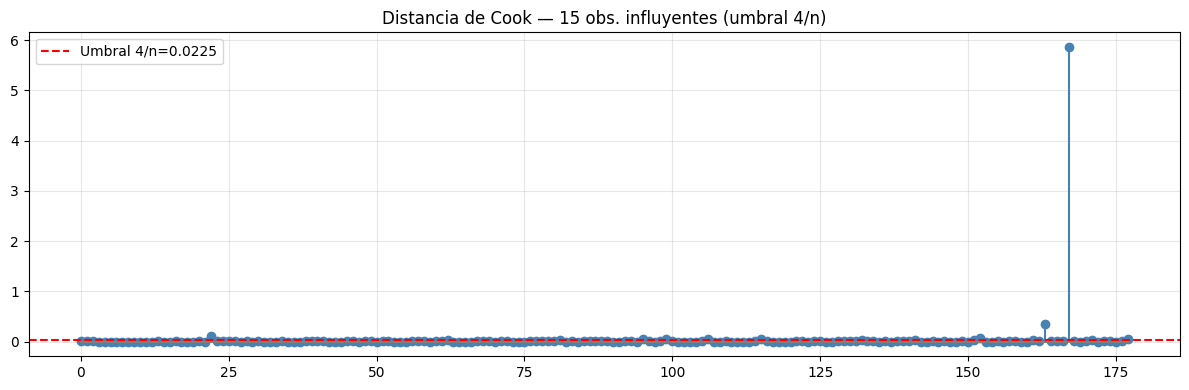

Observaciones influyentes: 15 (8.4%)
     precio_mxn      m2           tipo  banos_tot  dist_zocalo_km
22      1948993    26.0  departamentos        1.5       10.331195
63      4500000    89.0  departamentos        4.0       12.706081
96     22000000  1363.0          casas       13.0        4.462215
101     3000000   404.0          casas        4.0        2.509001
108    14000000   739.0          casas        6.0       12.745469
117    39000000   976.0          casas        5.0        6.299682
134     4800000   293.0          casas        4.0        2.091405
143    16500000   480.0          casas        5.0        5.067903
153    15000000   935.0          casas       12.5        4.486299
154    39700000   650.0          casas        5.0        4.896255
163     3500000   361.0          casas        5.5        1.954458
165    21000000  1350.0          casas        5.0        6.245799
169     8500000     4.0          casas       22.0        1.779261
173    11300000   439.0          casas 

In [24]:
# Cook's Distance — Influencia
influence = OLSInfluence(m3)
cook_d    = influence.cooks_distance[0]
umbral    = 4/len(df)
n_inf     = (cook_d > umbral).sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(range(len(cook_d)), cook_d, markerfmt='o', linefmt='steelblue',
        basefmt='gray')
ax.axhline(umbral, color='red', ls='--', lw=1.5, label=f'Umbral 4/n={umbral:.4f}')
ax.set_title(f'Distancia de Cook — {n_inf} obs. influyentes (umbral 4/n)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cook_distance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Observaciones influyentes: {n_inf} ({n_inf/len(df)*100:.1f}%)')
if n_inf > 0:
    idx = np.where(cook_d > umbral)[0]
    print(df.iloc[idx][['precio_mxn','m2','tipo','banos_tot','dist_zocalo_km']].to_string())

### Impacto de las Observaciones Influyentes en el Test RESET

Vamos a crear una versión de los datos sin las observaciones influyentes identificadas por la distancia de Cook para re-evaluar la especificación del modelo M3 con el test RESET.

In [25]:
# Crear una copia del DataFrame excluyendo las observaciones influyentes
# Convertir idx (indices posicionales) a los indices de etiqueta del DataFrame
idx_labels = df.index[idx]
df_filtered = df.drop(index=idx_labels).copy()

print(f"DataFrame original: {len(df)} observaciones")
print(f"DataFrame filtrado (sin influyentes): {len(df_filtered)} observaciones")

# Re-estimar el Modelo 3 con el DataFrame filtrado

y_filtered = df_filtered['ln_precio']

# Asegurarse de que las variables de interacción y logarítmicas existan en df_filtered
# (ya que se crearon en df y se copiaron al hacer drop, solo necesitamos usarlas)
VARS_BASE_M3 = ['banos_tot','estacionamientos',
                'roof_garden','alberca','es_casa']

VARS_I_M3 = VARS_BASE_M3 + ['inter_m2_casa','inter_m2_antiguedad',
                           'inter_banos_m2',
                           'ln_dist_zocalo']

X_m3_filtered = sm.add_constant(df_filtered[['ln_m2'] + VARS_I_M3 + ZONAS_DUMMIES])

m3_filtered = sm.OLS(y_filtered, X_m3_filtered).fit(cov_type='HC3')

print("\n--- Resumen del Modelo 3 re-estimado (sin influyentes) ---")
print(m3_filtered.summary())

DataFrame original: 178 observaciones
DataFrame filtrado (sin influyentes): 163 observaciones

--- Resumen del Modelo 3 re-estimado (sin influyentes) ---
                            OLS Regression Results                            
Dep. Variable:              ln_precio   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     81.18
Date:                Wed, 20 May 2026   Prob (F-statistic):           5.19e-62
Time:                        22:16:42   Log-Likelihood:                 18.589
No. Observations:                 163   AIC:                            -7.179
Df Residuals:                     148   BIC:                             39.23
Df Model:                          14                                         
Covariance Type:                  HC3                                         
                          coef    std err          z    

In [26]:
# Realizar el test RESET en el modelo filtrado (m3_filtered)
print('\n' + '='*55)
print('TEST RESET — Modelo 3 sin observaciones influyentes')
print('H0: modelo correctamente especificado')
print('='*55)

r_filtered = linear_reset(m3_filtered, power=3, use_f=True)
est_filtered = 'Posible mala especificacion' if r_filtered.pvalue < 0.05 else 'Especificacion correcta'
print(f'\nModelo 3 (filtrado): F={r_filtered.fvalue:.4f}  p={r_filtered.pvalue:.4f}  -> {est_filtered}')

# Comparar con el resultado original del Modelo 3
# (Asumiendo que 'r' from the previous RESET test is still available, or we re-calculate it)
print('\n--- Comparación con Modelo 3 original ---')
print(f'Modelo 3 (original): F={r.fvalue:.4f}  p={r.pvalue:.4f}  -> {est}')


TEST RESET — Modelo 3 sin observaciones influyentes
H0: modelo correctamente especificado

Modelo 3 (filtrado): F=1.1004  p=0.3355  -> Especificacion correcta

--- Comparación con Modelo 3 original ---
Modelo 3 (original): F=2.5109  p=0.0845  -> Especificacion correcta


Aunque el R cuadrado subió ligeramente al eliminar las observaciones, vemos que el p-value subió de manera significativa, aunque ambos pasan la prueba de especificación.

In [27]:
# Analisis de robustez

print('ROBUSTEZ — M3 completo vs M3-filtrado ')
print(f'  {"Variable":<22} {"M3 (n="+str(len(df))+")": >14} {"M3 filtrado": >14}  Delta%')
print(f'  {"-"*62}')
vars_rob = ['ln_m2','banos_tot','estacionamientos','roof_garden','alberca',
            'es_casa','inter_m2_casa','inter_m2_antiguedad','inter_banos_m2',
            'ln_dist_zocalo']
for var in vars_rob:
    if var in m3.params.index and var in m3_filtered.params.index:
        c2, c4 = m3.params[var], m3_filtered.params[var]
        d = (c4-c2)/abs(c2)*100 if c2!=0 else 0
        est = 'estable' if abs(d)<20 else 'CAMBIO GRANDE'
        print(f'  {var:<22} {c2:>14.4f} {c4:>14.4f}  {d:>+.1f}% {est}')

ROBUSTEZ — M3 completo vs M3-filtrado 
  Variable                   M3 (n=178)    M3 filtrado  Delta%
  --------------------------------------------------------------
  ln_m2                          0.8932         0.9685  +8.4% estable
  banos_tot                      0.2443         0.1303  -46.7% CAMBIO GRANDE
  estacionamientos               0.0654         0.0625  -4.4% estable
  roof_garden                    0.0630         0.0761  +20.8% CAMBIO GRANDE
  alberca                        0.1916         0.1797  -6.2% estable
  es_casa                       -0.1491        -0.1172  +21.4% CAMBIO GRANDE
  inter_m2_casa                  0.0007         0.0005  -32.3% CAMBIO GRANDE
  inter_m2_antiguedad           -0.0009        -0.0011  -15.9% estable
  inter_banos_m2                -0.0455        -0.0292  +35.9% CAMBIO GRANDE
  ln_dist_zocalo                -0.1246        -0.1503  -20.7% CAMBIO GRANDE


Este análisis muestra que **varios coeficientes del Modelo 3 no son robustos** ante la eliminación de las observaciones influyentes identificadas (cambios mayores al 20%). Específicamente, `banos_tot`, `roof_garden`, `es_casa`, `inter_m2_casa`, `inter_banos_m2` y `ln_dist_zocalo` mostraron 'CAMBIOS GRANDES'.

Esto sugiere que la interpretación de estos coeficientes debe hacerse con cautela, ya que sus valores son sensibles a la presencia de datos atípicos o muy influyentes en la muestra. Los demás coeficientes (`ln_m2`, `estacionamientos`, `alberca`, `inter_m2_antiguedad`) son más estables.

In [28]:
from google.colab import drive
drive.mount('/content/drive')
# Reemplaza la ruta si la carpeta ECONOMETRIA tiene acento o espacios diferentes
!jupyter nbconvert --to html "/content/drive/My Drive/ECONOMETRIA/Proyecto_Final.ipynb"

Mounted at /content/drive
[NbConvertApp] Converting notebook /content/drive/My Drive/ECONOMETRIA/Proyecto_Final.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1082766 bytes to /content/drive/My Drive/ECONOMETRIA/Proyecto_Final.html
